# Fitting of the analytical transfer function

In [21]:
# ----------------------------------------------------------------------------
# 1b. Mount Google Drive ------------------------------------------------------
# ----------------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not running in Colab: skipping Drive mount.')

Not running in Colab: skipping Drive mount.


In [22]:
# # CHECK THE LOCATION!
#import os
#os.getcwd()

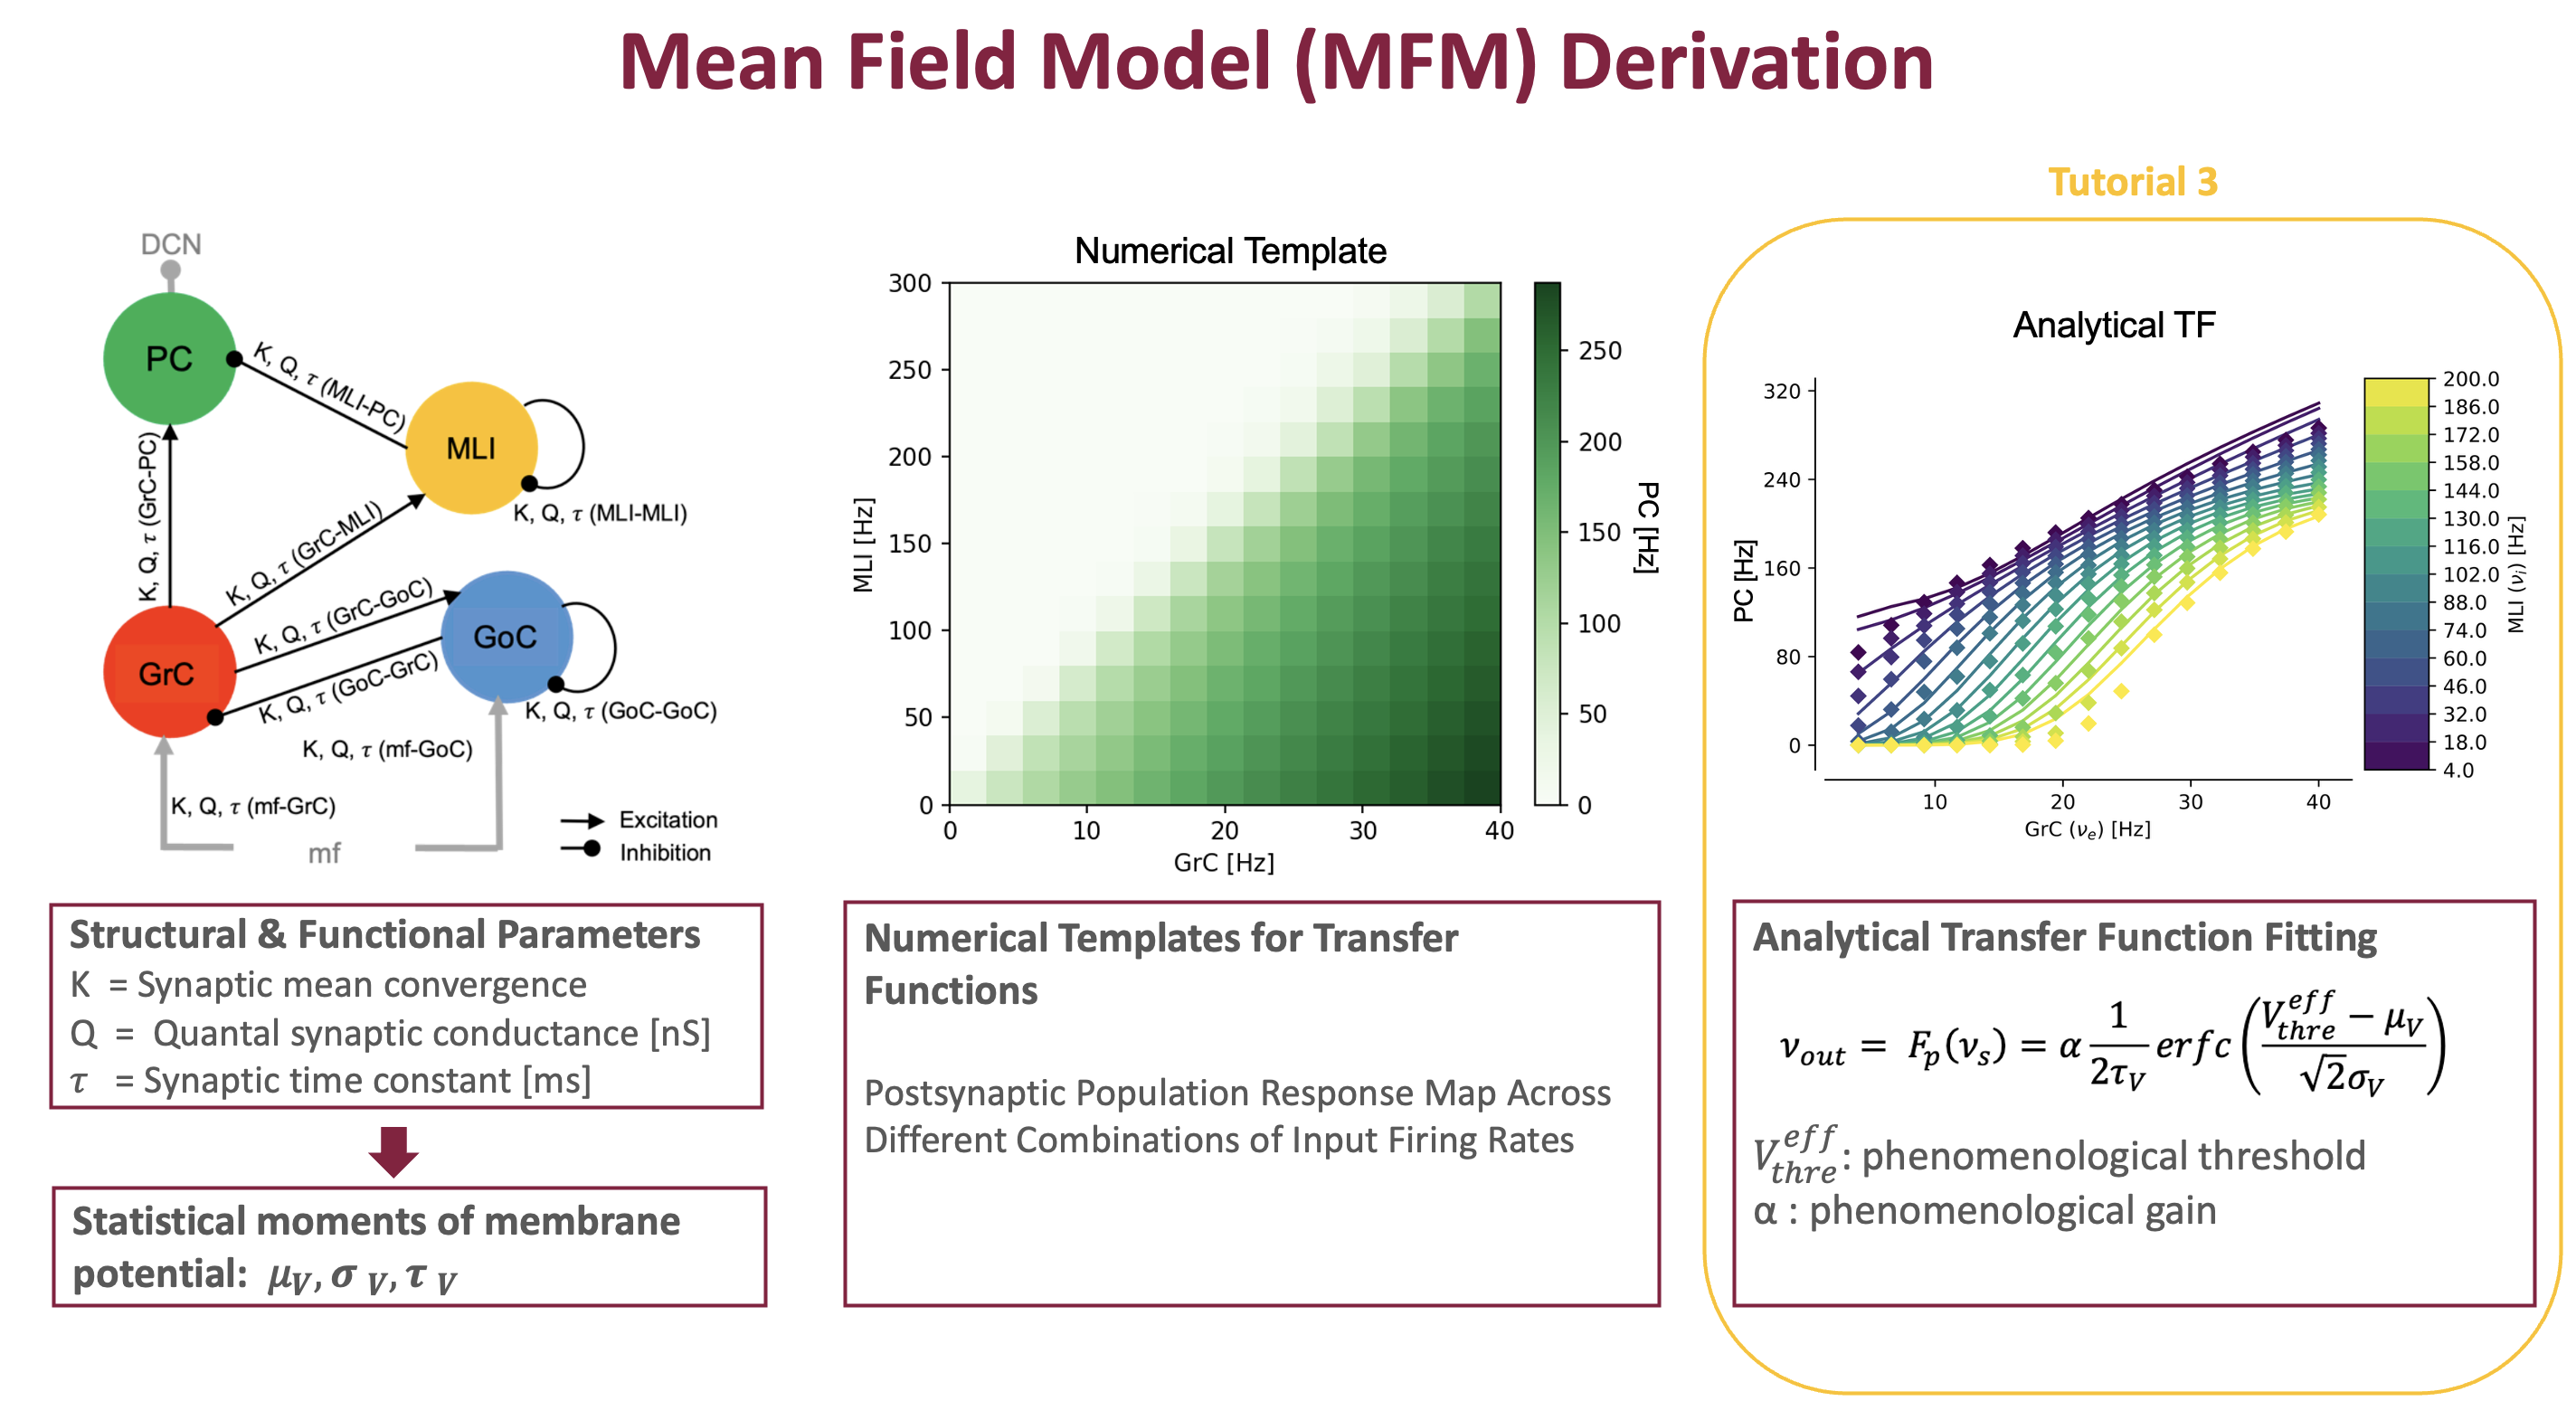

In [23]:
from IPython.display import Image, display
display(Image('figs/fig1.png'))

### Transfer function (TF)

TFs (F in the equation) are the core of this formalism, anabling us to translate single neuron properties to a mesoscale level by computing population-level conductances that in turns depend on the statistical moment of the membran potential fluctations(In the code: $\mu_V$  = average, $\sigma_V$ = standard deviation and $\tau_v$ = autocorrelation time (normalized)).

\begin{equation}
F_{out} = \nu_{out} = \alpha \frac{1}{2\tau_v} erfc (\frac{V^{eff}_{thre} - \mu_v}{\sqrt{2 \sigma_v}})
\end{equation}


According to Zerlaut et al.,2018, the analytical TF was derived from the numerical TF with the steps below:

**1 - Numerical TF** *see Tutorial 2*

For different couple of presynaptic fe,fi the numerical TF is computed for each population included in the network.
E.g. for the PC the presynaptic connection (i.e. the input frequency were GrC-PC (excitatory) and MLI-PC (inhibitory). **For the other population?**


**2 - Analytical TF**

Two step fitting procedure is implemented according to Zerlaut et al., 2018:

2.1) Fitting of the Phenomenological Threshold, accounting for single neuron specificity

2.2) Optimization of TF expression on numerical TF with LSQ method

Output: P coefficients of the phenomenological threshold that will be plugged into analytical TF

**Note**:
In the Auto-MFM a further multi-parametric optimization of the TF is implemented as follows:
- Fitting proceedure provides an *initialisation* of alpha-gains, specific for each population and fitted *independently* from other population activity.
- The MFM prediction can be further optimized based in *prediction*: SNN provides the gorund truth and alpha-gains are set as the free parameters of a multi-parametric multi-pbjectives optimization.
See here for further details about Auto-MFM!  https://doi.org/10.64898/2026.03.18.712631

here's the tool: https://github.com/RobertaMLo/Auto-MFM$
Soon released on cereb-modules: https://github.com/dbbs-lab/cerebellar-models$

In [24]:
pip install svgutils


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install numpy matplotlib scipy pandas seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy.special as sp_spec
import seaborn as sns
from my_graph import build_bar_legend, set_plot, get_linear_colormap

In [27]:
def pseq_params_eglif(params):
    Qe = params['Qe']
    Te, Ee = params['Te'], params['Ee']
    Qi, Ti, Ei = params['Qi'], params['Ti'], params['Ei']
    Gl, Cm, El = params['Gl'], params['Cm'], params['El']

    Ke = params['Ke']
    Ki = params['Ki']

    return Qe, Te, Ee, Qi, Ti, Ei, Gl, Cm, El, Ke, Ki

### Two-step fitting procedure of the phenomenological threshold

**Goal**: find the coefficients $P = (P_0, \dots, P_4)$ of $V^{eff}_{thre}$ such that the analytical TF reproduces the numerical TF obtained in Tutorial 2.

**Starting point**: for every point $(f_e, f_i)$ of the grid, the subthreshold statistics $\mu_V$, $\sigma_V$, $\tau_V$ (and $\mu_G$) are computed analytically from shot-noise theory (see function *get_fluct_regime_varsup_eglif*).

They do **not** depend on $P$. The only unknown in the TF is therefore the effective threshold $V^{eff}_{thre}$.


**1. TF expression (forward)** – `erfc_func`

$$
\nu_{out} = \frac{\alpha}{2\tau_V}\,\mathrm{erfc}\!\left(\frac{V^{eff}_{thre} - \mu_V}{\sqrt{2}\,\sigma_V}\right), \qquad \tau_V = \tau_V^N \frac{C_m}{g_L}
$$

**2. Inverse equation: threshold from the numerical TF** – `effective_Vthre`

Solving the TF for the threshold and replacing $\nu_{out}$ with the numerical rate:

$$
V^{eff}_{thre} = \mu_V + \sqrt{2}\,\sigma_V\,\mathrm{erfc}^{-1}\!\left(\frac{2\,\tau_V\,\nu_{num}}{\alpha}\right)
$$

where $\nu_{num}$ is a "point" in the numerical template computed in Tutorial 2. It is dependant on the input frequnecies; and it is defined for each $(f_e, f_i) pair input for the numerical TF

- $V^{eff}_{thre}$ is the threshold value that the analytical TF must have to reproduce exactly the rate of the numerical TF at a specific point of the grid


**3. Polynomial expression of the threshold (phenomenological)** – `threshold_func`

$$
V^{eff}_{thre}(P) = P_0 + P_1\frac{\mu_V - \mu_V^0}{\delta\mu_V} + P_2\frac{\sigma_V - \sigma_V^0}{\delta\sigma_V} + P_3\frac{\tau_V^N - \tau_V^{N0}}{\delta\tau_V^N} + P_4 \ln\!\left(\frac{\mu_G}{g_L}\right)
$$

with $\mu_V^0 = -60$ mV, $\delta\mu_V = 10$ mV, $\sigma_V^0 = 4$ mV, $\delta\sigma_V = 6$ mV, $\tau_V^{N0} = 0.5$, $\delta\tau_V^N = 1$ (Zerlaut et al., 2018)


**Note**: in this implementation the threshold is linear in the fluctuation variables plus a term in the normalised conductance $\mu_G/g_L$; the quadratic and mixed terms of Zerlaut et al., 2018 are not included.

<br><br>

**Step 1 – Fit in threshold space (equality of the two threshold expressions)**

At every retained grid point we impose

$$
V^{eff}_{thre,poly}(\mu_V, \sigma_V, \tau_V^N, \mu_G;\,P) = V^{eff}_{thre,num}
$$

Since $\mu_V, \sigma_V, \tau_V^N, \mu_G$ are known, this is an overdetermined system **linear in $P$**. It is solved by minimising $\mathrm{MSE}\big(V^{eff}_{thre,num} - V^{eff}_{thre,poly}(P)\big)$ (first `Res` in `fitting_Vthre_then_Fout_eglif`).

<br><br>

**Step 2 – Fit in rate space**

$P$ from step 1 is used as initial condition to minimise the error directly on the firing rate over the whole grid:

$$
\min_P\ \mathrm{MSE}\big(\nu_{num} - \nu_{TF}(f_e, f_i;\,P)\big)
$$

(second `Res`, Nelder–Mead).


### Phenomenological threshold $ V^{eff}_{thre} $



In [28]:
# EQUATION OF ERFC = vout = Fout = TF expression (Zerlaut et al. 2018)
def erfc_func(muV, sV, TvN, Vthre, Gl, Cm, alpha):
    return .5 / TvN * Gl / Cm * (sp_spec.erfc((Vthre - muV) / np.sqrt(2) / sV)) * alpha


# EQUATION OF VOUT obtained by inverting erfc_func above (Zerlaut et al. 2016)
# Used in first step of fitting procedure (fitting of V eff thre expression)
# Y = TF numerical template
def effective_Vthre(Y, muV, sV, TvN, Gl, Cm, alpha):
    Vthre_eff = muV + np.sqrt(2) * sV * sp_spec.erfcinv((1 / alpha) * (Y * 2 * TvN * Cm / Gl))  # effective threshold

    return Vthre_eff


# Polynomia expression of V eff thre - initial condition
def threshold_func(muV, sV, TvN, muGn, P0, P1, P2, P3, P4):
    """
    setting by default to True the square
    because when use by external modules, coeff[5:]=np.zeros(3)
    in the case of a linear threshold
    """

    muV0, DmuV0 = -60e-3, 10e-3
    sV0, DsV0 = 4e-3, 6e-3
    TvN0, DTvN0 = 0.5, 1.



    return P0 + P1 * (muV - muV0) / DmuV0 + \
           P2 * (sV - sV0) / DsV0 + P3 * (TvN - TvN0) / DTvN0 + P4 * np.log(muGn)
    # return P0+0*muV


### Statistics of the membrane potential with $\mu_V ; \sigma_V ; \tau_V$

In [29]:
def plot_MF_statistics(muGe, muGi, muG, muV, sV, Tv):
    media = sns.heatmap(muV)
    plt.title('Average Membrane Potential [V]')
    plt.xlabel('Fe [Hz]')
    plt.ylabel('Fi [Hz]')
    plt.show()
    var = sns.heatmap(sV)
    plt.title('Membrane Potential StDev [V]')
    plt.xlabel('Fe [Hz]')
    plt.ylabel('Fi [Hz]')
    plt.show()
    tau = sns.heatmap(Tv)
    plt.title('Autocorrelation Time [s]')
    plt.xlabel('Fe [Hz]')
    plt.ylabel('Fi [Hz]')
    plt.show()
    mug = sns.heatmap(muG)
    plt.title('Target neuron conductance [S]')
    plt.xlabel('Fe [Hz]')
    plt.ylabel('Fi [Hz]')
    plt.show()

def get_fluct_regime_varsup_eglif(Fe, Fi, XX,
                                  Qe, Te, Ee, Qi, Ti, Ei, Gl, Cm, El, Ke, Ki, P0):
    fe = Fe
    fi = Fi

    # ---------------------------- Pop cond:  mu GrC and MLI ---------------------------------------
    muGe, muGi = Qe * Ke * Te * fe, Qi * Ki * Ti * fi  # EQUAL TO EXP
    # ---------------------------- Input cond:  mu PC -----------------------------------------------
    muG = Gl + muGe + muGi  # EQUAL TO EXP
    # ---------------------------- Membrane Fluctuation Properties ----------------------------------

    """
    print('MEMBRANE FLUCT PROP')
    print('Qe: ',Qe,'\tTe: ',Te,'\tEe: ',Ee,'\tKe: ',Ke,
          '\nQi: ',Qi,'\tTi: ',Ti,'\tEi: ',Ei,'\tKi: ',Ki,
          '\nGl: ',Gl,'\t Cm: ',Cm,'\tEl: ',El)

    print('Conductances')
    print('muGe: ', muGe,'\tmuGi: ',muGi)
    """
    muV = (np.e * (muGe * Ee + muGi * Ei + Gl * El) - XX) / muG  # XX = adaptation

    """
    print('MuV without adap: ', (np.e * (muGe * Ee + muGi * Ei + Gl * El) / muG) )
    print('MuV with adap: ', muV)
    """

    muGn, Tm = muG / Gl, Cm / muG  # normalization

    Ue, Ui = Qe / muG * (Ee - muV), Qi / muG * (Ei - muV)  # EQUAL TO EXP

    # sVe= (2*Tm + Te) * (np.e * Ue *Te) ** 2 / (2* (Te + Tm)) **2 *Ke * fe
    # sVi = (2*Tm + Ti) * (np.e * Ui *Ti) ** 2 / (2* (Ti + Tm)) **2 *Ki * fi

    sVe = (2 * Tm + Te) * ((np.e * Ue * Te) / (2 * (Te + Tm))) ** 2 * Ke * fe
    sVi = (2 * Tm + Ti) * ((np.e * Ui * Ti) / (2 * (Ti + Tm))) ** 2 * Ki * fi

    sV = np.sqrt(sVe + sVi)

    fe, fi = fe + 1e-9, fi + 1e-9  # just to insure a non zero division

    Tv_num = Ke * fe * Ue ** 2 * Te ** 2 * np.e ** 2 + Ki * fi * Ui ** 2 * Ti ** 2 * np.e ** 2
    Tv = 0.5 * Tv_num / ((sV + 1e-20) ** 2)

    TvN = Tv * Gl / Cm  # normalization

    #plot_MF_statistics(muGe, muGi, muG, muV, sV, Tv)

    return muGe, muGi, muG, muV, sV + 1e-20, muGn, TvN, Tv

### Definition of the TF

In [30]:
def TF_my_templateup_eglif(fe, fi, XX, alpha, Qe, Te, Ee, Qi, Ti, Ei, Gl, Cm, El, Ke, Ki,
                           P0, P1, P2, P3, P4):
    # here TOTAL (sum over synapses) excitatory and inhibitory input

    muGe, muGi, muG, muV, sV, muGn, TvN, Tv = get_fluct_regime_varsup_eglif(fe, fi, XX, Qe, Te, Ee,
                                                                            Qi, Ti, Ei, Gl, Cm, El,
                                                                            Ke, Ki,
                                                                            P0)

    Vthre = threshold_func(muV, sV, TvN, muGn, P0, P1, P2, P3, P4)

    Fout_th = erfc_func(muV, sV, TvN, Vthre, Gl, Cm, alpha)

    return Fout_th

### Fitting procedure

In [31]:
def fitting_Vthre_then_Fout_eglif(Fout, Fe_eff, fiSim, w, params, alpha,
                                  maxiter=50000, xtol=1e-5):
    Gl, Cm, El = params['Gl'], params['Cm'], params['El']

    muGe, muGi, muG, muV, sV, muGn, TvN, Tv = get_fluct_regime_varsup_eglif(Fe_eff, fiSim, w,
                                                                            *pseq_params_eglif(params), -50e-3)

    #foutlim = 70.
    foutlim= Fout.max()
    Qe, Te, Ee, Qi, Ti, Ei, Gl, Cm, El, Ke, Ki = pseq_params_eglif(params)

    print('PARAMS in FITTING:')
    print('Qe=', Qe,'\nTe=', Te, '\nEe=',Ee,
          '\nQi=',Qi, '\nTi=',Ti, '\nEi=', Ei,
          '\nGl=',Gl, '\nCm=',Cm, '\nEl=',El,
          '\nKe=',Ke, '\nKi=',Ki)


    i_non_zeros = np.where((Fout > 0.) & (Fout < foutlim))  # GrC - based on trial and error
    print("Fout Limit: ", foutlim)

    Vthre_eff = effective_Vthre(Fout[i_non_zeros], muV[i_non_zeros], \
                                sV[i_non_zeros], TvN[i_non_zeros], params['Gl'], params['Cm'], alpha)

    P = [-50e-3, 0, 0, 0, 0]
    # P[:5] = Vthre_eff.mean(), 1e-3, 1e-3, 1e-3, 1e-3



    print("OPTIMIZATION STEP 1 ==========================================\nVthre Optimization")

    def Res(p):
        vthre = threshold_func(muV[i_non_zeros], sV[i_non_zeros], TvN[i_non_zeros],
                               muGn[i_non_zeros], *p)
        return np.mean((Vthre_eff - vthre) ** 2)

    # plsq = minimize(Res, P, method='SLSQP', options={'ftol': 1e-15, 'disp': True, 'maxiter': 40000})

    plsq = minimize(Res, P, options={'disp': True})
    P = plsq.x

    print('========== P output from Vthreshold opt: ', P)

    print("OPTIMIZATION STEP 2 ==========================================\nFout Optimization")

    def Res(p):
        return np.mean((Fout -
                        TF_my_templateup_eglif(Fe_eff, fiSim, w, alpha,
                                               params['Qe'], params['Te'], params['Ee'], params['Qi'], params['Ti'],
                                               params['Ei'], params['Gl'], params['Cm'], params['El'], params['Ke'],
                                               params['Ki'], *p)) ** 2)

    plsq = minimize(Res, P, method='nelder-mead',
                    options={'xtol': xtol, 'disp': True, 'maxiter': maxiter})

    # plsq = minimize(Res, P, options={'disp': True})
    P = plsq.x
    print('========== P output from Fout opt: ', P)

    print("END OF OPTIMIZATION PROCESS ==========================================")

    params['P'] = P

    return P

### Parameters definition and upload of the numerical TF

In [32]:
#params = np.load('GrC_params', allow_pickle = True).item()

In [ ]:
# check single cell paremeters && weights here:
#https://github.com/dbbs-lab/cerebellar-models/blob/feature/auto_mfm/circuit_Z-.yaml
#N.B. note that weights has to be renamed as Q, tau_syn1 = Te; tau_syn2 = Ti

# check synaptic parameters here:
#tutorial 2 - table: "convergence". Don't take into account standard deviation
#N.B. convergence has to be called K.

params_yaml = {
    'name': 'GrC', 'N': 1,
          'A1': 0.01,
          'A2': -0.94,
          'C_m': 7,
          'E_L': -62,
          'E_rev1': 0,
          'E_rev2': -80,
          'I_e': -0.888,
          'V_m': -62.0,
          'V_min': -150,
          'delta_v': 2.5,
          'V_reset': -70,
          'V_th': -41,
          'k_1': 0.311,
          'k_2': 0.041407868,
          'k_adap': 0.022,
          'lambda_0': 1.0,
          't_ref': 1.5,
          'tau_V': 0.3,
          'tau_m': 24.15,
          'Te': 5.8,
          'Ti': 13.61,
          'Ke': 4,
          'Ki': 3.6,
          'Qi': 0.23,
          'Qe': 0.24,
          'Gl':7/24.15

}

In [ ]:
def my_converter(params):
    # MILLI V to V ---------------------------------------------------------------------------------
    params['El'] = 1e-3 * params['E_L']
    params['Vthre'] = 1e-3 * params['V_th']
    params['Vreset'] = 1e-3 * params['V_reset']
    params['delta_v'] = 1e-3 * params['delta_v']
    if 'vspike' in params: params['vspike'] = 1e-3 * params['vspike']

    # MILLI s to s -----------------------------------------------------------------------------
    if 'tm' in params: params['tm'] = 1e-3 * params['tm']
    params['Trefrac'] = 1e-3 * params['t_ref']

    # KILO Hz to Hz --> (ms)^-1 to s^-1 --> (10^-3)^-1 = 10^3 ----------------------------------
    if 'k2' in params: params['k2'] = 1e3 * params['k2']
    if 'k1' in params: params['k1'] = 1e3 * params['k1']

    # (MEGA H)^-1 to H^-1 --> (10^6)^-1 = 10^-6 -------------------------------------------------
    if 'kadap' in params: params['kadap'] = 1e-6 * params['kadap']

    # NANO S to S ------------------------------------------------------------------------------
    if 'a' in params: params['a'] = 1e-9 * params['a']
    params['Gl'] = 1e-9 * params['Gl']

    # PICO A to A -------------------------------------------------------------------------------
    if 'b' in params: params['b'] = 1e-12 * params['b']
    if 'A2' in params: params['A2'] = 1e-12 * params['A2']
    if 'A1' in params: params['A1'] = 1e-12 * params['A1']
    if 'Ie' in params: params['Ie'] = 1e-12 * params['Ie']

    # PICO F to F -------------------------------------------------------------------------------
    params['Cm'] = 1e-12 * params['C_m']

      # NANO SIEMENS ----> SIEMENS
    if 'Qe' in params:
        params['Qe'] *= 1e-9
    if 'Qi' in params:
        params['Qi'] *= 1e-9
    if 'Qe_ext' in params:
        params['Qe_Ext'] *= 1e-9

    # MILLI SEC and MILLI VOLT ----> SEC and VOLT
    params['Ee'] = params['E_rev1']*1e-3
    params['Ei'] = params['E_rev2']*1e-3

    if 'E_ext' in params:
      params['Ee_ext'] *= 1e-3
    params['Ti'] *= 1e-3
    params['Te'] *= 1e-3

    if 'Te_ext' in params:
      params['Te_ext'] *= 1e-3

    return params.copy()

In [35]:
params = my_converter(params_yaml)
print(params)

{'name': 'GrC', 'N': 1, 'A1': 1e-14, 'A2': -9.399999999999998e-13, 'C_m': 7, 'E_L': -62, 'E_rev1': 0, 'E_rev2': -80, 'I_e': -0.888, 'V_m': -62.0, 'V_min': -150, 'delta_v': 0.0025, 'V_reset': -70, 'V_th': -41, 'k_1': 0.311, 'k_2': 0.041407868, 'k_adap': 0.022, 'lambda_0': 1.0, 't_ref': 1.5, 'tau_V': 0.3, 'tau_m': 24.15, 'Te': 0.0058, 'Ti': 0.01361, 'Ke': 4, 'Ki': 3.6, 'Qi': 2.3000000000000003e-10, 'Qe': 2.4e-10, 'Gl': 2.8985507246376814e-10, 'El': -0.062, 'Vthre': -0.041, 'Vreset': -0.07, 'Trefrac': 0.0015, 'Cm': 7e-12, 'Ee': 0.0, 'Ei': -0.08}


In [36]:
import numpy as np
z = np.load('./Numerical_TFs/TF_granule_cell.npz')

z.files

['tf_mean', 'tf_std', 'tags', 'freq_axis_mf', 'freq_axis_GoC']

In [37]:
MEANfreq = z['tf_mean'].T
SDfreq = z['tf_std']
Fi = z['freq_axis_GoC']
Fe = z['freq_axis_mf']

w = np.zeros((len(Fi), len(Fe)))

# frequencies saved into matrices for the broadcasting.
fiSim = np.ones((len(Fi), len(Fe)))
Fe_eff = np.ones((len(Fi), len(Fe)))

#fi (goc)
fiSim = (fiSim*Fi).T #freq changes on the row (required .T)

#Fe mossy - driving input
Fe_eff = (Fe_eff*Fe)



In [38]:
alpha = 4.5
P = fitting_Vthre_then_Fout_eglif(MEANfreq, Fe_eff, fiSim, w, params, alpha)

print('==================================================')
print(1e3 * np.array(P), 'Fitted P in mV')

# then we save it:
cell_name = params['name']
filename = cell_name + '_alpha'+str(alpha)+'_fit.npy'
print('coefficients P saved in ', filename)
np.save(filename, np.array(P))



PARAMS in FITTING:
Qe= 2.4e-10 
Te= 0.0058 
Ee= 0.0 
Qi= 2.3000000000000003e-10 
Ti= 0.01361 
Ei= -0.08 
Gl= 2.8985507246376814e-10 
Cm= 7e-12 
El= -0.062 
Ke= 4 
Ki= 3.6
Fout Limit:  211.44444444444446
OPTIMIZATION STEP 1 ==========================================
Vthre Optimization
Optimization terminated successfully.
         Current function value: 0.000053
         Iterations: 26
         Function evaluations: 174
         Gradient evaluations: 29
========== P output from Vthreshold opt:  [-0.29434921 -0.0016036   0.01239398  0.09634604  0.10212896]
OPTIMIZATION STEP 2 ==========================================
Fout Optimization
Optimization terminated successfully.
         Current function value: 7.510337
         Iterations: 175
         Function evaluations: 283
========== P output from Fout opt:  [-0.27465804 -0.00142505  0.00929461  0.10773039  0.09805351]
END OF OPTIMIZATION PROCESS ==========================================
[-274.65803946   -1.42504874    9.29460861  107.

/var/folders/yy/ctbv3djj6x5frvb6qzps8j7w0000gn/T/ipykernel_3104/3024179662.py:53: OptimizeWarning: Unknown solver options: xtol
  plsq = minimize(Res, P, method='nelder-mead',


In [39]:
def plot_TF_numerical_vs_analytical_2D(MEANfreq, SDfreq, fiSim, Fe_eff_grc, w,
                                                     P, alpha, params, xname, barname, FOLDER, facW):

        w = w / facW
        fiSim = fiSim[:, 0]
        fiSim = np.meshgrid(np.zeros(Fe_eff_grc.shape[1]), fiSim)[1]
        levels = np.unique(fiSim)  # to store for colors

        if P is not None:
            params['P'] = P

        # # #### FIGURE AND COLOR GRADIENT STUFF

        fig1 = plt.figure(figsize=(6, 4))
        plt.subplots_adjust(bottom=.2, left=.15, right=.85, wspace=.2)
        ax = plt.subplot2grid((1, 8), (0, 0), colspan=7)
        ax_cb = plt.subplot2grid((1, 8), (0, 7))

        # -- Setting up a colormap that's a simple transtion
        mymap = plt.cm.viridis
        #mymap = get_linear_colormap()
        build_bar_legend(np.round(levels, 1), levels.size, ax_cb, mymap,
                         label=barname + ' ($\\nu_i$)' + ' [Hz]')  # BUILD THE COLOR SCALE BAR

        for i in range(levels.size):
            SIMvector = MEANfreq[i][:]
            SDvector = SDfreq[i][:]
            feSim = Fe_eff_grc[i][:]
            feth = np.linspace(feSim.min(), feSim.max(), int(1e2))
            fi = fiSim[i][0]
            wee = w[i][0]

            #print("Adap:", wee)

            _, _, _, muV, sV, muGn, TvN, Tv = get_fluct_regime_varsup_eglif(feSim, fi, wee,
                                                                                   *pseq_params_eglif(params),
                                                                                   P[0])

            # Fout_th = erfc_func(muV, sV, TvN, -56e-3, params['Gl'], params['Cm']) # JUST FIXING THE THRESHOLD FOR NOW

            Fout_th = erfc_func(muV, sV, TvN, threshold_func(muV, sV, TvN, muGn, *P), params['Gl'], params['Cm'], alpha)

            # cond = Fout_th < 40.
            cond = Fout_th <= Fout_th.max()

            r = (float(levels[i]) - levels.min()) / (levels.max() - levels.min())
            #### plot dei pallini - template numerico
            ax.errorbar(feSim[cond], SIMvector[cond], yerr=SDvector[cond], \
                        color=mymap(r, 1), marker='D', ms=5, capsize=3, elinewidth=1, lw=0)

            #### plot delle linee - espressione con error function di TF
            ax.plot(feSim[cond], Fout_th[cond], color=mymap(r, 1))


        set_plot(ax, ['bottom', 'left'], xlabel=xname+' ($\\nu_{e}$)'+ ' [Hz]', \
                 ylabel='$\\nu_{out}$'+ ' [Hz]')

        #### SOLO PER PLOT ZEBRINE POS NEG
        #ax.set_ylim(0, 125)
        #ax.set_yticks(np.linspace(0, 125, 5, dtype =int))


        ## quantitative analysis
        diff = np.absolute(np.array([SIMvector - Fout_th]))
        print('QUANTUTATIVE SCORE!!!!!\n diff (numTF-SemiAnalyticTF)', diff)


        print('----------------------------------------')
        diff_mean = diff.mean()
        diff_sd = diff.std()
        diff_max = diff.max()
        diff_min = diff.min()
        print('Mean diff +- stdev (numTF-SemiAnalyticTF)', diff_mean, '+-', diff_sd)
        print('Min diff', diff_min)

        plt.savefig(FOLDER+'_alfa'+str(alpha)+'.pdf',dpi=300)

        plt.show()


def call_plot_fitting(FOLDER, alpha, MEANfreq, sd_freq, w, fiSim, Fe_m_eff, params, xname, barname):
    max_index_fi = len(fiSim)
    max_ind_fe = len(Fe_m_eff)

    MEANfreq = MEANfreq[:max_index_fi, :max_ind_fe]
    SDfreq = sd_freq[:max_index_fi, :max_ind_fe]
    fiSim = fiSim[:max_index_fi, :max_ind_fe]
    Fe_eff_m = Fe_m_eff[:max_index_fi, :max_ind_fe]
    w = w[:max_index_fi, :max_ind_fe]
    P = np.load(FOLDER + '_alpha' + str(alpha) + '_fit.npy', allow_pickle=True)

    plot_TF_numerical_vs_analytical_2D(MEANfreq, SDfreq, fiSim, Fe_eff_m, w,
                                                 P, alpha, params, xname, barname, FOLDER, facW=1)

QUANTUTATIVE SCORE!!!!!
 diff (numTF-SemiAnalyticTF) [[0.01002879 0.01451938 0.02059977 0.02866632 0.03916354 0.0525783
  0.0694319  0.09027027 0.11565253 0.14613873 0.18227697 0.11347936
  0.27356516 0.2185269  0.3931866  0.35340888 0.32164905 0.18694732
  0.06048031 0.3866698 ]]
----------------------------------------
Mean diff +- stdev (numTF-SemiAnalyticTF) 0.15386199335757242 +- 0.12646219903170705
Min diff 0.010028788783173412


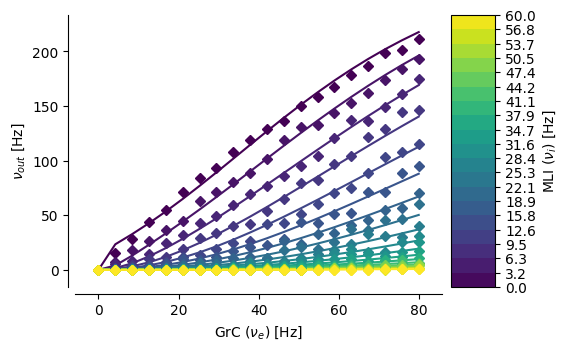

In [40]:
xname = 'GrC'
barname = 'MLI'
call_plot_fitting(cell_name, alpha, MEANfreq, SDfreq, w, fiSim, Fe_eff, params, xname, barname)

### Congrats! You fit your Granule transfer function!!!!!

###...... **Now it's your turn!**

Launch the fitting procedure for another cerebellar-specific population:

- PC Z- : Still a PC but with a different expression of the ADOLASE-C enzyme. Parameters are defined here: https://github.com/dbbs-lab/cerebellar-models/blob/feature/auto_mfm/circuit_Z-.yaml

What is changing compared to PC Z+?

- MLI : Molecular Interneurons including basket and stellate cells -- Pay attention you need to merge stellate and basket and ascending axons and parallel fibers

- GoC: the population of a 3D transfer function!

<br><br>
**References**

- CRBL MF: Lorenzi et al., 2023 (https://doi.org/10.1371/journal.pcbi.1011434)
- AUTO-MFM : Lorenzi et al., 2026 (https://doi.org/10.64898/2026.03.18.712631)
- E-GLIF: Geminiani et al 2018, 2019 (https://doi.org/10.3389/fninf.2018.00088 and https://doi.org/10.3389/fncom.2019.00035)
- Mathematics: Boustani and Destexhe 2009 (https://doi.org/10.1162/neco.2009.02-08-710)
- TF formalism: Zerlaut et al. 2018 (https://doi.org/10.1007/s10827-017-0668-2)
- TF Fitting procedure: Zerlaut et al. 2016  (https://doi.org/10.1113/JP272317)
- MF with adaptation: Di Volo et al. 2019 (https://doi.org/10.1162/neco_a_01173)
- MF review for different neuron model: Carlu et al. 2020 (https://doi.org/10.1152/jn.00399.2019)